## Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import overpy
from geopy.distance import geodesic
import overpy
import time

## Read Data Set

In [2]:
df1 = pd.read_excel(r'C:\Users\ASUS\Desktop\New folder\datastorm-7-0-rotaract\Data\row\1. dataset_description.xlsx')
df2 = pd.read_csv(r'C:\Users\ASUS\Desktop\New folder\datastorm-7-0-rotaract\Data\row\distributor_seasonality_details.csv',encoding='latin1')
df3 = pd.read_csv(r'C:\Users\ASUS\Desktop\New folder\datastorm-7-0-rotaract\Data\row\holiday_list.csv',encoding='latin1')
df4 = pd.read_csv(r'C:\Users\ASUS\Desktop\New folder\datastorm-7-0-rotaract\Data\row\outlet_coordinates.csv',encoding='latin1')
df5 = pd.read_csv(r'C:\Users\ASUS\Desktop\New folder\datastorm-7-0-rotaract\Data\row\outlet_master.csv',encoding='latin1')
df6 = pd.read_csv(r'C:\Users\ASUS\Desktop\New folder\datastorm-7-0-rotaract\Data\row\transactions_history_final.csv',encoding='latin1')


## Data Cleaning and Preprocessing

### ** df1 Data Set

In [3]:
df1.head()

,Dataset Name,Column Name,Data Type,Description
0,transactions_history.csv,Outlet_ID,String,Unique identifier for the retail outlet.
1,NaN,Year,Integer,"Transaction year (2023, 2024, 2025)."
2,NaN,Month,Integer,Transaction month (1 to 12).
3,NaN,Distributor_ID,String,Identifier for the 10 distributors.
4,NaN,SKU_ID,String,Unique identifier for the product.


In [4]:
df1.shape

(22, 4)

In [5]:
df1.columns

Index(['Dataset Name', 'Column Name', 'Data Type', 'Description'], dtype='object')

In [6]:
df1.columns = df1.columns.str.strip()

In [7]:
df1 =df1.drop_duplicates()

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Dataset Name  5 non-null      object
 1   Column Name   22 non-null     object
 2   Data Type     22 non-null     object
 3   Description   22 non-null     object
dtypes: object(4)
memory usage: 836.0+ bytes


In [9]:
df1.isnull().sum()

Dataset Name    17
Column Name      0
Data Type        0
Description      0
dtype: int64

In [10]:
df1['Dataset Name'] = df1['Dataset Name'].fillna("Unknown")

In [11]:
df1.isnull().sum()

Dataset Name    0
Column Name     0
Data Type       0
Description     0
dtype: int64

### ** df2 Data Set

In [12]:
df2.head()

,Distributor_ID,Year,Month,Seasonality_Index
0,DIST_W_01,2023,1,Moderate
1,DIST_W_01,2023,2,Moderate
2,DIST_W_01,2023,3,Moderate
3,DIST_W_01,2023,4,Favorable
4,DIST_W_01,2023,5,Un-Favorable


In [13]:
df2.shape

(360, 4)

In [14]:
df2.columns

Index(['Distributor_ID', 'Year', 'Month', 'Seasonality_Index'], dtype='object')

In [15]:
df2.columns=df2.columns.str.strip()

In [16]:
df2=df2.drop_duplicates()

In [17]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Distributor_ID     360 non-null    object
 1   Year               360 non-null    int64 
 2   Month              360 non-null    int64 
 3   Seasonality_Index  360 non-null    object
dtypes: int64(2), object(2)
memory usage: 11.4+ KB


In [18]:
df2.isnull().sum()

Distributor_ID       0
Year                 0
Month                0
Seasonality_Index    0
dtype: int64

### ** df3 Data Set

In [19]:
df3.head()

,Date,Holiday_Name,Holiday_Type
0,2023-01-06T00:00:00Z,Duruthu Full Moon Poya Day,Public
1,2023-01-15T00:00:00Z,Tamil Thai Pongal Day,Public
2,2023-01-16T00:00:00Z,Additional Holiday in lieu of Tamil Thai Ponga...,Public
3,2023-02-03T00:00:00Z,Additional Half Holiday in lieu of the Indepen...,Public
4,2023-02-04T00:00:00Z,National Day,Public


In [20]:
df3.shape

(349, 3)

In [21]:
df3.columns

Index(['Date', 'Holiday_Name', 'Holiday_Type'], dtype='object')

In [22]:
df3.columns=df3.columns.str.strip()

In [23]:
df3.drop_duplicates()

,Date,Holiday_Name,Holiday_Type
0,2023-01-06T00:00:00Z,Duruthu Full Moon Poya Day,Public
1,2023-01-15T00:00:00Z,Tamil Thai Pongal Day,Public
2,2023-01-16T00:00:00Z,Additional Holiday in lieu of Tamil Thai Ponga...,Public
3,2023-02-03T00:00:00Z,Additional Half Holiday in lieu of the Indepen...,Public
4,2023-02-04T00:00:00Z,National Day,Public
...,...,...,...
344,2025-09-07T00:00:00Z,Binara Full Moon Poya Day,Mercantile
345,2025-10-06T00:00:00Z,Vap Full Moon Poya Day,Mercantile
346,2025-11-05T00:00:00Z,Ill Full Moon Poya Day,Mercantile
347,2025-12-04T00:00:00Z,Unduvap Full Moon Poya Day,Mercantile


In [24]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          349 non-null    object
 1   Holiday_Name  349 non-null    object
 2   Holiday_Type  349 non-null    object
dtypes: object(3)
memory usage: 8.3+ KB


In [25]:
df3.isnull().sum()

Date            0
Holiday_Name    0
Holiday_Type    0
dtype: int64

### ** df4 Data Set

In [26]:
df4.head()

,Outlet_ID,Latitude,Longitude
0,OUT_00001,7.089846,79.979055
1,OUT_00002,7.000558,80.012422
2,OUT_00003,6.806170,79.854547
3,OUT_00004,6.703533,79.806919
4,OUT_00005,7.186878,79.869831


In [27]:
df4.shape

(20000, 3)

In [28]:
df4.columns

Index(['Outlet_ID', 'Latitude', 'Longitude'], dtype='object')

In [29]:
df4.columns=df4.columns.str.strip()

In [30]:
df4 = df4.drop_duplicates()

In [31]:
df4.isnull().sum()

Outlet_ID    0
Latitude     0
Longitude    0
dtype: int64

### ** df5 Data Set

In [32]:
df5.head()

,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type
0,OUT_00001,Medium,1,Grocry
1,OUT_00002,Small,0,Hotel
2,OUT_00003,Small,1,Pharmacy
3,OUT_00004,Medium,2,Pharmacy
4,OUT_00005,Medium,2,Kiosk


In [33]:
df5.shape

(20000, 4)

In [34]:
df5.columns

Index(['Outlet_ID', 'Outlet_Size', 'Cooler_Count', 'Outlet_Type'], dtype='object')

In [35]:
df5.columns=df5.columns.str.strip()

In [36]:
df5 = df5.drop_duplicates()

In [37]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Outlet_ID     20000 non-null  object
 1   Outlet_Size   19804 non-null  object
 2   Cooler_Count  20000 non-null  int64 
 3   Outlet_Type   20000 non-null  object
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


In [38]:
df5.isnull().sum()

Outlet_ID         0
Outlet_Size     196
Cooler_Count      0
Outlet_Type       0
dtype: int64

In [39]:
df5['Outlet_Size'] = df5['Outlet_Size'].fillna("Unknown")

In [40]:
df5.isnull().sum()

Outlet_ID       0
Outlet_Size     0
Cooler_Count    0
Outlet_Type     0
dtype: int64

### ** df6 Data Set

In [41]:
df6.head()

,Outlet_ID,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value
0,OUT_19886,2024,12,DIST_S_02,SKU_10,5.897879,2177.632359
1,OUT_00837,2024,2,DIST_W_01,SKU_03,20.697364,7244.084814
2,OUT_15438,2025,12,DIST_NW_01,SKU_02,55.101801,13959.108787
3,OUT_12992,2025,1,DIST_C_01,SKU_07,24.063953,15641.548773
4,OUT_12334,2025,5,DIST_C_02,SKU_04,47.769665,15525.158656


In [42]:
df6.shape

(2376389, 7)

In [43]:
df6.columns

Index(['Outlet_ID', 'Year', 'Month', 'Distributor_ID', 'SKU_ID',
       'Volume_Liters', 'Total_Bill_Value'],
      dtype='object')

In [44]:
df6.columns = df6.columns.str.strip()

In [45]:
df6.drop_duplicates()

,Outlet_ID,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value
0,OUT_19886,2024,12,DIST_S_02,SKU_10,5.897879,2177.632359
1,OUT_00837,2024,2,DIST_W_01,SKU_03,20.697364,7244.084814
2,OUT_15438,2025,12,DIST_NW_01,SKU_02,55.101801,13959.108787
3,OUT_12992,2025,1,DIST_C_01,SKU_07,24.063953,15641.548773
4,OUT_12334,2025,5,DIST_C_02,SKU_04,47.769665,15525.158656
...,...,...,...,...,...,...,...
2376384,OUT_00825,2025,9,DIST_W_01,SKU_07,20.305661,13198.669945
2376385,OUT_15184,2024,8,DIST_NW_02,SKU_07,61.105053,39718.314060
2376386,OUT_09232,2025,3,DIST_C_01,SKU_09,14.505651,31912.430033
2376387,OUT_19669,2025,10,DIST_S_02,SKU_02,40.923617,10367.278716


In [46]:
df6.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2376389 entries, 0 to 2376388
Data columns (total 7 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Outlet_ID         object 
 1   Year              int64  
 2   Month             int64  
 3   Distributor_ID    object 
 4   SKU_ID            object 
 5   Volume_Liters     float64
 6   Total_Bill_Value  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 126.9+ MB


In [47]:
df6.isnull().sum()

Outlet_ID           0
Year                0
Month               0
Distributor_ID      0
SKU_ID              0
Volume_Liters       0
Total_Bill_Value    0
dtype: int64

In [48]:
df = df6.copy()

df = pd.merge(df, df5, on="Outlet_ID", how="left")
df = pd.merge(df, df4, on="Outlet_ID", how="left")
df = pd.merge(df, df2, on=["Distributor_ID", "Year", "Month"], how="left")

df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")
df3["Date"] = pd.to_datetime(df3["Date"]).dt.tz_localize(None)
df["Date"] = df["Date"].dt.tz_localize(None)

df = pd.merge(df, df3, on="Date", how="left")

In [49]:
df.head()

,Outlet_ID,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value,Outlet_Size,Cooler_Count,Outlet_Type,Latitude,Longitude,Seasonality_Index,Date,Holiday_Name,Holiday_Type
0,OUT_19886,2024,12,DIST_S_02,SKU_10,5.897879,2177.632359,Small,0,Hotel,6.222572,80.230934,Favorable,2024-12-01,NaN,NaN
1,OUT_00837,2024,2,DIST_W_01,SKU_03,20.697364,7244.084814,Large,4,Kiosk,7.024894,79.831030,Moderate,2024-02-01,NaN,NaN
2,OUT_15438,2025,12,DIST_NW_01,SKU_02,55.101801,13959.108787,Medium,1,Grocery,7.537159,80.103760,Favorable,2025-12-01,NaN,NaN
3,OUT_12992,2025,1,DIST_C_01,SKU_07,24.063953,15641.548773,Medium,2,Bakery,7.152607,80.666430,Moderate,2025-01-01,NaN,NaN
4,OUT_12334,2025,5,DIST_C_02,SKU_04,47.769665,15525.158656,Extra Large,5,Kiosk,6.994638,80.647910,Moderate,2025-05-01,May Day,Public


## Get Data From API

In [50]:
api = overpy.Overpass()

def count_pois(lat, lon, tag_key, tag_value, radius=1000):

    try:

        query = f"""
        (
          node
            ["{tag_key}"="{tag_value}"]
            (around:{radius},{lat},{lon});
        );
        out body;
        """

        result = api.query(query)

        return len(result.nodes)

    except:
        return 0

In [51]:
def get_poi_count(lat, lon):
    key = (round(lat,4), round(lon,4))

    if key in cache:
        return cache[key]

    query = f'(node["amenity"="hospital"](around:2000,{lat},{lon}););out body;'

    try:
        result = api.query(query)
        count = len(result.nodes)
    except:
        count = 0

    cache[key] = count
    return count

In [52]:
api = overpy.Overpass(url="https://overpass.kumi.systems/api/interpreter")

In [53]:
cache = {}
def get_poi_features(lat, lon):

    key = (round(lat,4), round(lon,4))

    if key in cache:
        return cache[key]

    query = f"""
    (
      node["amenity"="school"](around:2000,{lat},{lon});
      node["amenity"="hospital"](around:2000,{lat},{lon});
      node["amenity"="restaurant"](around:2000,{lat},{lon});
      node["amenity"="bank"](around:2000,{lat},{lon});
      node["tourism"="hotel"](around:2000,{lat},{lon});
      node["highway"="bus_stop"](around:2000,{lat},{lon});
    );
    out;
    """

    try:
        result = api.query(query)

        features = {
            "school_count": 0,
            "hospital_count": 0,
            "restaurant_count": 0,
            "bank_count": 0,
            "hotel_count": 0,
            "bus_stop_count": 0
        }

        for n in result.nodes:
            if n.tags.get("amenity") == "school":
                features["school_count"] += 1
            if n.tags.get("amenity") == "hospital":
                features["hospital_count"] += 1
            if n.tags.get("amenity") == "restaurant":
                features["restaurant_count"] += 1
            if n.tags.get("amenity") == "bank":
                features["bank_count"] += 1
            if n.tags.get("tourism") == "hotel":
                features["hotel_count"] += 1
            if n.tags.get("highway") == "bus_stop":
                features["bus_stop_count"] += 1

    except:
        features = {
            "school_count": 0,
            "hospital_count": 0,
            "restaurant_count": 0,
            "bank_count": 0,
            "hotel_count": 0,
            "bus_stop_count": 0
        }

    cache[key] = features
    time.sleep(1)   # IMPORTANT for API safety


In [54]:
def get_poi_counts(lat, lon):

    api = overpy.Overpass()

    pois = {}

    poi_queries = {
        "schools": '["amenity"="school"]',
        "hospitals": '["amenity"="hospital"]',
        "bus_stops": '["highway"="bus_stop"]',
        "restaurants": '["amenity"="restaurant"]'
    }

    for name, tag in poi_queries.items():

        query = f"""
        (
          node
            {tag}
            (around:1000,{lat},{lon});
        );
        out body;
        """

        try:
            result = api.query(query)
            pois[name] = len(result.nodes)

        except:
            pois[name] = 0

    return pois

In [ ]:
poi_features = []

for index, row in df.head(100).iterrows():

    lat = row['Latitude']
    lon = row['Longitude']

    poi = get_poi_counts(lat, lon)

    poi_features.append(poi)

poi_df = pd.DataFrame(poi_features)

In [ ]:
df = pd.concat([df.reset_index(drop=True), poi_df], axis=1)

In [ ]:
poi_df.hist(figsize=(10,6))
plt.suptitle("POI Feature Distribution")
plt.show()

In [ ]:
df.shape

(2970083, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2970083 entries, 0 to 2970082
Data columns (total 14 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Outlet_ID          object        
 1   Year               int64         
 2   Month              int64         
 3   Distributor_ID     object        
 4   SKU_ID             object        
 5   Volume_Liters      float64       
 6   Total_Bill_Value   float64       
 7   Outlet_Size        object        
 8   Cooler_Count       int64         
 9   Outlet_Type        object        
 10  Latitude           float64       
 11  Longitude          float64       
 12  Seasonality_Index  object        
 13  Date               datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(3), object(6)
memory usage: 317.2+ MB


In [ ]:
df.isnull().sum()

Outlet_ID                  0
Year                       0
Month                      0
Distributor_ID             0
SKU_ID                     0
Volume_Liters              0
Total_Bill_Value           0
Outlet_Size                0
Cooler_Count               0
Outlet_Type                0
Latitude                   0
Longitude                  0
Seasonality_Index          0
Date                       0
Holiday_Name         2112543
Holiday_Type         2112543
dtype: int64

In [ ]:
df = df.drop(columns=["Holiday_Name", "Holiday_Type"])

In [ ]:
df.to_csv(r"C:\Users\ASUS\Desktop\New folder\datastorm-7-0-rotaract\Data\processed\DataXnova_predictions.csv", index=False)

NameError: name 'df' is not defined

In [ ]:
df.columns

Index(['Outlet_ID', 'Year', 'Month', 'Distributor_ID', 'SKU_ID',
       'Volume_Liters', 'Total_Bill_Value', 'Outlet_Size', 'Cooler_Count',
       'Outlet_Type', 'Latitude', 'Longitude', 'Seasonality_Index', 'Date'],
      dtype='object')

In [ ]:
df.describe()

,Year,Month,Volume_Liters,Total_Bill_Value,Cooler_Count,Latitude,Longitude,Date
count,2.970083e+06,2.970083e+06,2.970083e+06,2.970083e+06,2.970083e+06,2.970083e+06,2.970083e+06,2970083
mean,2.023934e+03,6.399374e+00,5.096866e+01,1.335442e+04,2.073050e+00,7.766819e+00,7.926045e+01,2024-05-19 15:59:22.114996480
min,2.023000e+03,1.000000e+00,-9.564408e+02,-1.411536e+05,0.000000e+00,0.000000e+00,0.000000e+00,2023-01-01 00:00:00
25%,2.023000e+03,4.000000e+00,9.779720e+00,3.413380e+03,1.000000e+00,6.815114e+00,7.992331e+01,2023-08-01 00:00:00
50%,2.024000e+03,6.000000e+00,2.233544e+01,7.825144e+03,2.000000e+00,7.022360e+00,8.005439e+01,2024-05-01 00:00:00
75%,2.025000e+03,9.000000e+00,5.265311e+01,1.583401e+04,3.000000e+00,7.353649e+00,8.044623e+01,2025-03-01 00:00:00
max,2.025000e+03,1.200000e+01,9.438578e+03,1.528457e+05,5.000000e+00,8.079232e+01,8.079995e+01,2025-12-01 00:00:00
std,8.273757e-01,3.156333e+00,9.296411e+01,1.604209e+04,1.555105e+00,7.405100e+00,8.188827e+00,NaN


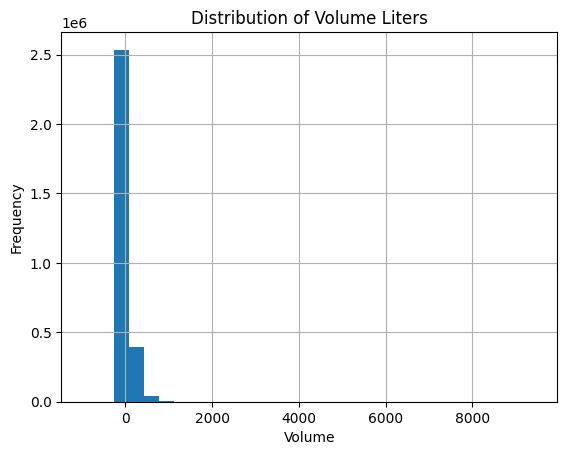

In [ ]:
df['Volume_Liters'].hist(bins=30)
plt.title("Distribution of Volume Liters")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

## Feature Engineering

In [ ]:
avg_sales = df.groupby('Outlet_ID')['Volume_Liters'].mean().reset_index()
avg_sales.columns = ['Outlet_ID', 'Avg_Monthly_Sales']

In [ ]:
max_sales = df.groupby('Outlet_ID')['Volume_Liters'].max().reset_index()
max_sales.columns = ['Outlet_ID', 'Max_Historical_Sales']

In [ ]:
sales_frequency = df.groupby('Outlet_ID').size().reset_index(name='Sales_Frequency')

In [ ]:
gold = avg_sales.merge(max_sales, on='Outlet_ID')
gold = gold.merge(sales_frequency, on='Outlet_ID')

In [ ]:
gold['Maximum_Monthly_Liters'] = (
    gold['Max_Historical_Sales'] * 1.25
)


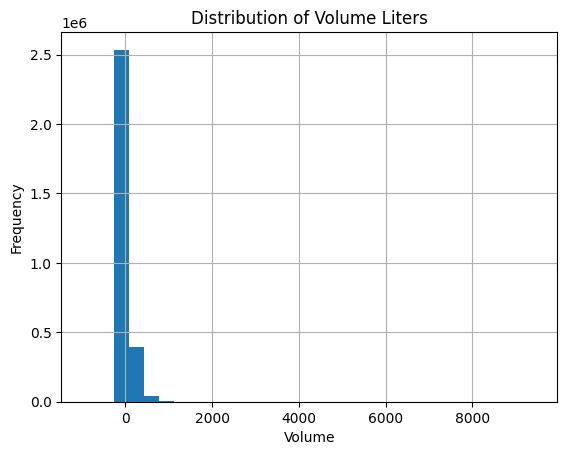

In [ ]:
df['Volume_Liters'].hist(bins=30)
plt.title("Distribution of Volume Liters")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

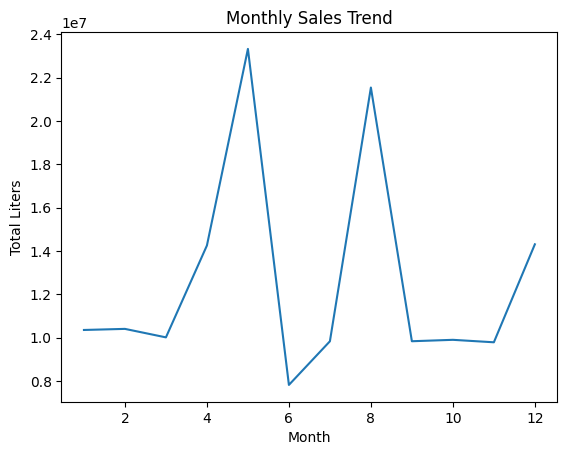

In [ ]:
monthly_sales = df.groupby('Month')['Volume_Liters'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.ylabel("Total Liters")
plt.show()

In [ ]:
gold['Pseudo_Target'] = (
    gold['Avg_Monthly_Sales'] * 1.3
)

In [ ]:
X = gold[[
    'Avg_Monthly_Sales',
    'Max_Historical_Sales',
    'Sales_Frequency'
]]

y = gold['Pseudo_Target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
predictions = model.predict(X)

gold['Maximum_Monthly_Liters'] = predictions

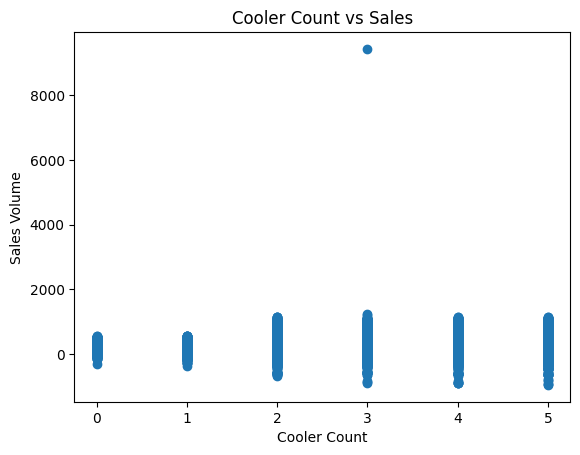

In [ ]:
plt.scatter(df['Cooler_Count'], df['Volume_Liters'])
plt.xlabel("Cooler Count")
plt.ylabel("Sales Volume")
plt.title("Cooler Count vs Sales")
plt.show()